<a href="https://colab.research.google.com/github/d-kumar-yadav/Neural_network/blob/main/ann_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

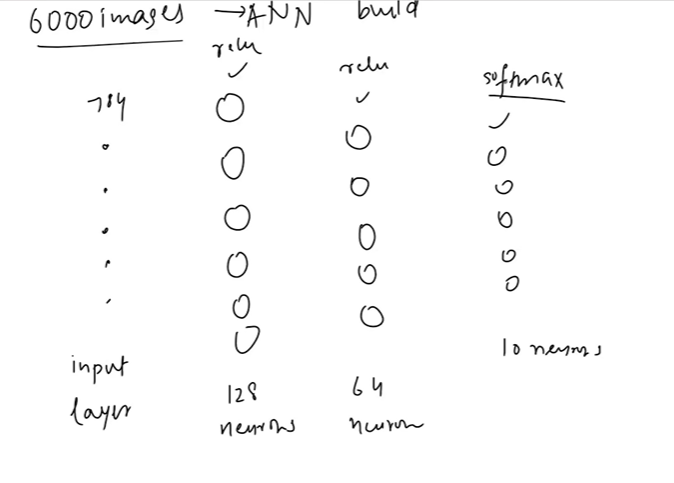

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [75]:
torch.manual_seed(42)

In [76]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [77]:
device

'cuda'

In [78]:
df= pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
len(df)

60000

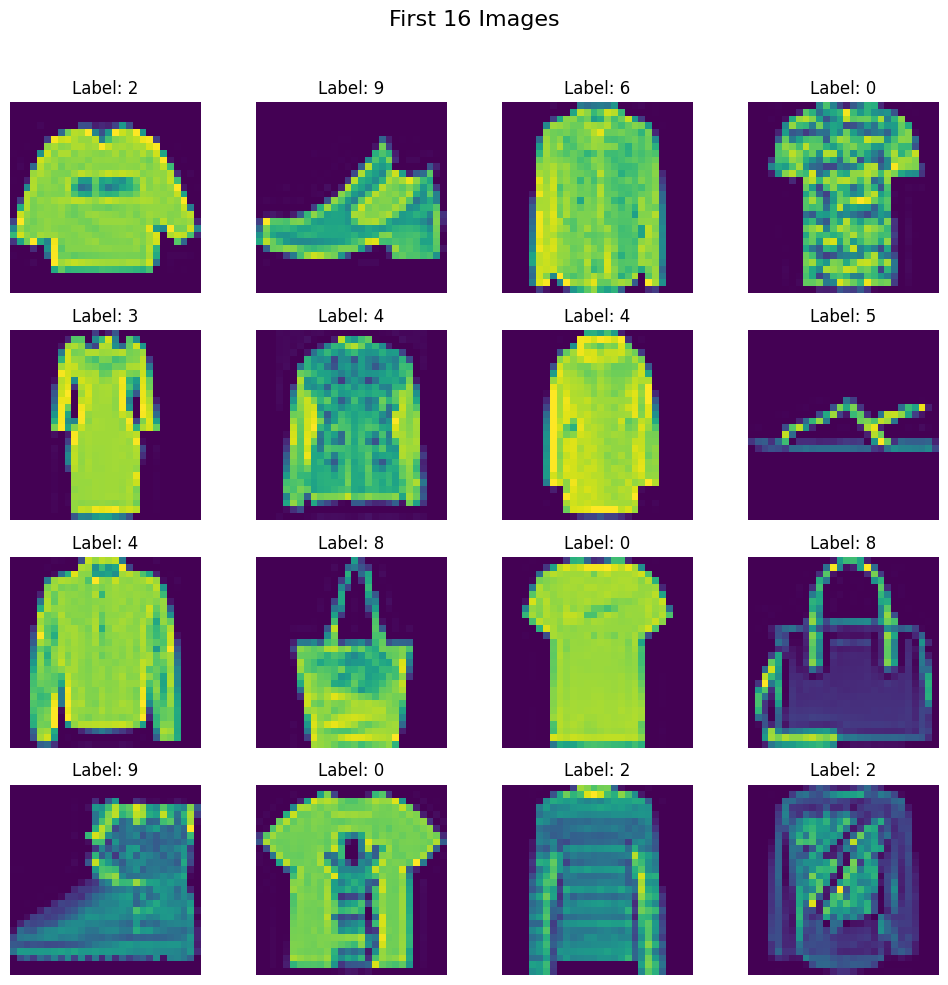

In [80]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [81]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, 1:].values, df.iloc[:, 0].values, test_size=0.2)

In [82]:
x_train=x_train/255.0
x_test=x_test/255.0

In [83]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [84]:
class fashiondataset(Dataset):
    def __init__(self,features ,labels):
      self.features = torch.tensor(features, dtype=torch.float32)
      self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
      return len(self.features)

    def __getitem__(self, index):
       return self.features[index] , self.labels[index]



In [85]:
train_dataset=fashiondataset(x_train,y_train)
test_dataset=fashiondataset(x_test,y_test)

**Hyperparameter Tunning**

In [86]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)



In [87]:
# objective function
def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [88]:
# from torch.nn.modules.dropout import Dropout
# class neural(nn.Module):
#   def __init__(self , feature):
#     super().__init__()
#     self.model= nn.Sequential(
#         nn.Linear(feature, 128),
#         nn.BatchNorm1d(128),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),
#         nn.Linear(128, 64),
#         nn.BatchNorm1d(64),
#         nn.ReLU(),
#         nn.Dropout(p=0.3),
#         nn.Linear(64, 10)
#     )
#   def forward(self ,feature):
#     return self.model(feature)

In [89]:
!pip install optuna

In [90]:
import optuna

study = optuna.create_study(direction='maximize')  # accuracy =maximise  ,loss= minismise

[I 2026-08-21 14:46:15,872] A new study created in memory with name: no-name-f57fd1b4-8031-407f-a49b-4336914b8e9e


In [91]:
study.optimize(objective, n_trials=10)

[I 2026-08-21 14:46:32,872] Trial 0 finished with value: 0.8614166666666667 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 32, 'epochs': 20, 'learning_rate': 0.05523908140517084, 'dropout_rate': 0.5, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 4.118083116969448e-05}. Best is trial 0 with value: 0.8614166666666667.
[I 2026-08-21 14:50:46,397] Trial 1 finished with value: 0.8223333333333334 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 56, 'epochs': 50, 'learning_rate': 0.004290388831879363, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0003482725135899254}. Best is trial 0 with value: 0.8614166666666667.
[I 2026-08-21 14:51:31,170] Trial 2 finished with value: 0.7285833333333334 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 16, 'epochs': 30, 'learning_rate': 0.0007408104457378894, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00028342216650726763}. B

In [92]:
study.best_value

0.8903333333333333

In [93]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 80,
 'epochs': 40,
 'learning_rate': 0.00012214079815757602,
 'dropout_rate': 0.1,
 'batch_size': 32,
 'optimizer': 'Adam',
 'weight_decay': 3.689053098052483e-05}

In [95]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:
    #move  featur and label to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9387708333333333


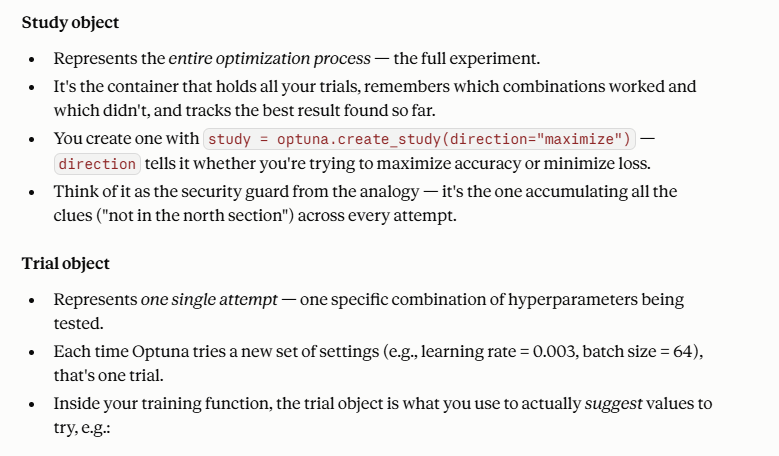

**Hyperparameter**

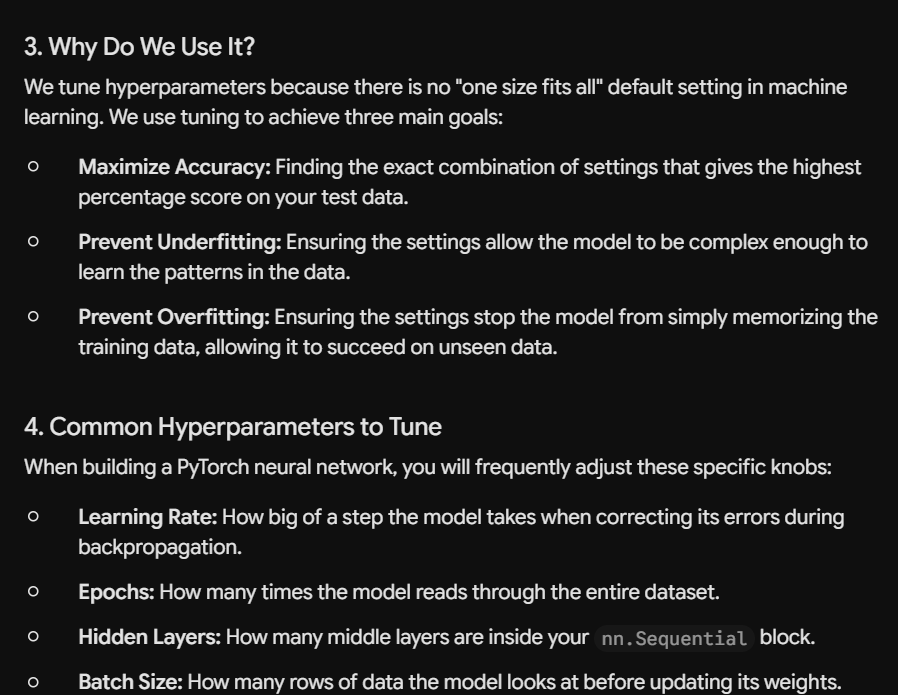





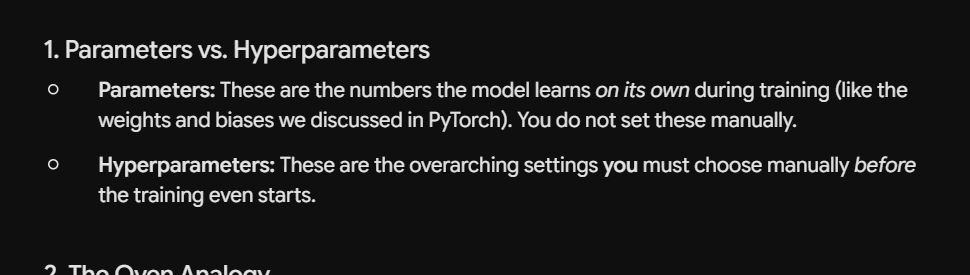




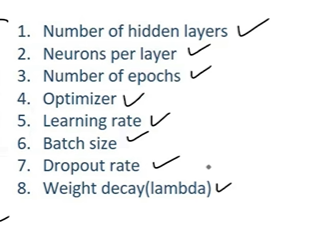


1. Grid Search (The Brute Force Method)
How it works: You give the computer a specific list of numbers to try for each setting. The computer tests every single possible combination of those numbers.

The Analogy: Imagine you lost your keys in a grid-like parking lot. Grid Search means walking through every single parking space, one by one, until you check the entire lot.

The Code: In Scikit-learn, this is called GridSearchCV.

The Catch: It guarantees you will find the best combination from your list, but if you have a lot of settings, it can take hours or even days to run because it tests thousands of combinations.

2. Random Search (The "Good Enough" Method)
How it works: Instead of testing every single combination, you give the computer a range of numbers, and it picks combinations completely at random for a set amount of time.

The Analogy: You randomly drop into 50 different spots in the parking lot to look for your keys.

The Code: In Scikit-learn, this is called RandomizedSearchCV.

Why it is actually great: It sounds worse than Grid Search, but mathematically, it is often much better! It finds a highly accurate model in a fraction of the time because it doesn't waste time testing tiny, useless variations (like checking learning rates of 0.010, 0.011, and 0.012).

3. Bayesian Optimization (The Smart Method)
How it works: This is an AI that tunes your AI. Instead of guessing randomly or checking a rigid grid, it looks at its past mistakes. If a learning rate of 0.5 caused a terrible accuracy score, it completely avoids numbers near 0.5 for the next test. It plays a game of "Hot or Cold" to quickly hunt down the best settings.

The Analogy: You ask a security guard where your keys might be, and they say "not in the north section." You immediately focus only on the south section, getting closer with every clue.

The Code: The most popular Python library for this right now is called Optuna.

The Catch: It is the industry standard for Deep Learning (like PyTorch), but requires writing a few extra lines of code to set up compared to Scikit-learn's built-in tools.